# 03 - Background consistency

Background-only checks (seconds) on the parent/daughter densities:

- **C1 closure:** the component densities sum to the critical density today.
- **C2 parent analytic form:** ρ_parent = f_acc ρ_cdm (1 − a^κ)/(1 + (a/a_t)^κ).
- **C3 Γ_acc:** the stored depletion rate equals −(1/a) d ln(a³ρ_parent)/dτ from the table.
- **C4 normalization:** each parent becomes one daughter of the same rest mass, so today
  Ω_daughter/Ω_cdm = f_acc, slightly above it by the daughters' leftover kinetic energy. This catches
  a daughter that comes out too light.

Model: m = 10¹⁶ GeV, η = 0.1, κ = 12.1, a_t = 0.133, strategy-5 grid at 101 bins/decade.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from accdm_nb import KAPPA, A_T, accdm_params, born_fraction, run_class, plot_style

plot_style()

MASS, ETA, F_FID = 1e16, 0.1, 0.1
GRID = {'accdm_q_bins_per_decade': 101, 'accdm_q_number_tol': 1e-8}


def background(f_acc, eta=ETA):
    """Background table sorted by increasing a, with 'a' added."""
    out = run_class(accdm_params(f_acc, MASS, eta=eta, **GRID), lambda c: {'bg': c.get_background()})
    assert 'error' not in out, out['error']
    bg = out['bg']
    a = 1/(1 + np.asarray(bg['z']))
    order = np.argsort(a)
    return {'a': a[order], **{k: np.asarray(v)[order] for k, v in bg.items()}}


bg = background(F_FID)
a, rho_p, rho_d = bg['a'], bg['(.)rho_acc_cdm'], bg['(.)rho_ncdm[1]']
print('Omega_acc today = {:.5f}'.format(rho_d[-1]/bg['(.)rho_crit'][-1]))

Omega_acc today = 0.02414


## C1 closure

In [2]:
rho_keys = [k for k in bg if k.startswith('(.)rho_') and k not in ('(.)rho_crit', '(.)rho_tot')]
closure = sum(bg[k][-1] for k in rho_keys)/bg['(.)rho_crit'][-1]
Omega_m = (bg['(.)rho_b'][-1] + bg['(.)rho_cdm'][-1] + rho_d[-1])/bg['(.)rho_crit'][-1]
print('sum rho_i / rho_crit - 1 = {:.1e} over {}'.format(closure - 1, ', '.join(k[3:] for k in rho_keys)))
print('Omega_m = {:.4f}'.format(Omega_m))
assert abs(closure - 1) < 1e-6
assert 0.25 < Omega_m < 0.35
print('C1 passed')

sum rho_i / rho_crit - 1 = 0.0e+00 over rho_g, rho_b, rho_cdm, rho_ncdm[0], rho_ncdm[1], rho_lambda, rho_ur, rho_acc_cdm, rho_de_acc
Omega_m = 0.3145
C1 passed


## C2 parent analytic form

Compared where the parent is still above 10⁻³ of its early value.

In [3]:
rho_p_analytic = F_FID*bg['(.)rho_cdm']*(1 - born_fraction(a))
m = rho_p_analytic > 1e-3*F_FID*bg['(.)rho_cdm']
dev = float(np.max(np.abs(rho_p[m]/rho_p_analytic[m] - 1)))
print('max |rho_parent / analytic - 1| = {:.1e}'.format(dev))
assert dev < 1e-5
print('C2 passed')

max |rho_parent / analytic - 1| = 5.2e-14
C2 passed


## C3 Γ_acc consistency

In conformal time the comoving parent a³ρ depletes at aΓ, with Γ the physical rate CLASS stores.
Compared on a ∈ [0.05, 0.5], away from a = 1 and the flat early times; the numerical derivative
limits the agreement, so the median is asserted.

In [4]:
tau, gamma = bg['conf. time [Mpc]'], bg['Gamma_acc']
gamma_num = -np.gradient(np.log(a**3*rho_p), tau)/a
band = (a > 0.05) & (a < 0.5)
rel = np.abs(gamma_num[band]/gamma[band] - 1)
print('|Gamma_num / Gamma_acc - 1| on a in [0.05, 0.5]: median {:.1e}, max {:.1e}'.format(np.median(rel), rel.max()))
assert np.median(rel) < 0.03
print('C3 passed')

|Gamma_num / Gamma_acc - 1| on a in [0.05, 0.5]: median 1.5e-06, max 2.3e-04
C3 passed


/var/folders/63/hsv392l91zx26klpnndgtnm00000gn/T/ipykernel_63442/3338431671.py:2: RuntimeWarning: divide by zero encountered in log
  gamma_num = -np.gradient(np.log(a**3*rho_p), tau)/a


## C4 normalization

In [5]:
F_SEQ = [0.05, 0.1, 0.2, 0.5]
runs_f = {f: background(f) for f in F_SEQ}
print('{:>6} {:>14} {:>12}'.format('f_acc', 'Om_d / Om_cdm', 'ratio / f_acc'))
ratios = []
for f, b in runs_f.items():
    r = b['(.)rho_ncdm[1]'][-1]/b['(.)rho_cdm'][-1]
    ratios.append(r/f)
    print('{:>6g} {:>14.5f} {:>12.5f}'.format(f, r, r/f))
assert max(abs(r - 1) for r in ratios) < 0.03, 'daughter normalization off by more than 3%'
assert min(ratios) >= 0.999, 'daughter lighter than its parents'
print('C4 passed')

 f_acc  Om_d / Om_cdm ratio / f_acc
  0.05        0.05010      1.00194
   0.1        0.10019      1.00194
   0.2        0.20039      1.00194
   0.5        0.50097      1.00194
C4 passed


## Densities across f_acc and η

Left: parent (solid) and daughter (dashed) densities for several f_acc; the amplitude scales with f_acc,
the timing does not. Right: comoving energy of the accDM sector at several η, normalized to its early
value. It rises by about η during production as the daughters are born with kinetic energy, then
falls back towards the rest-mass value as they cool.

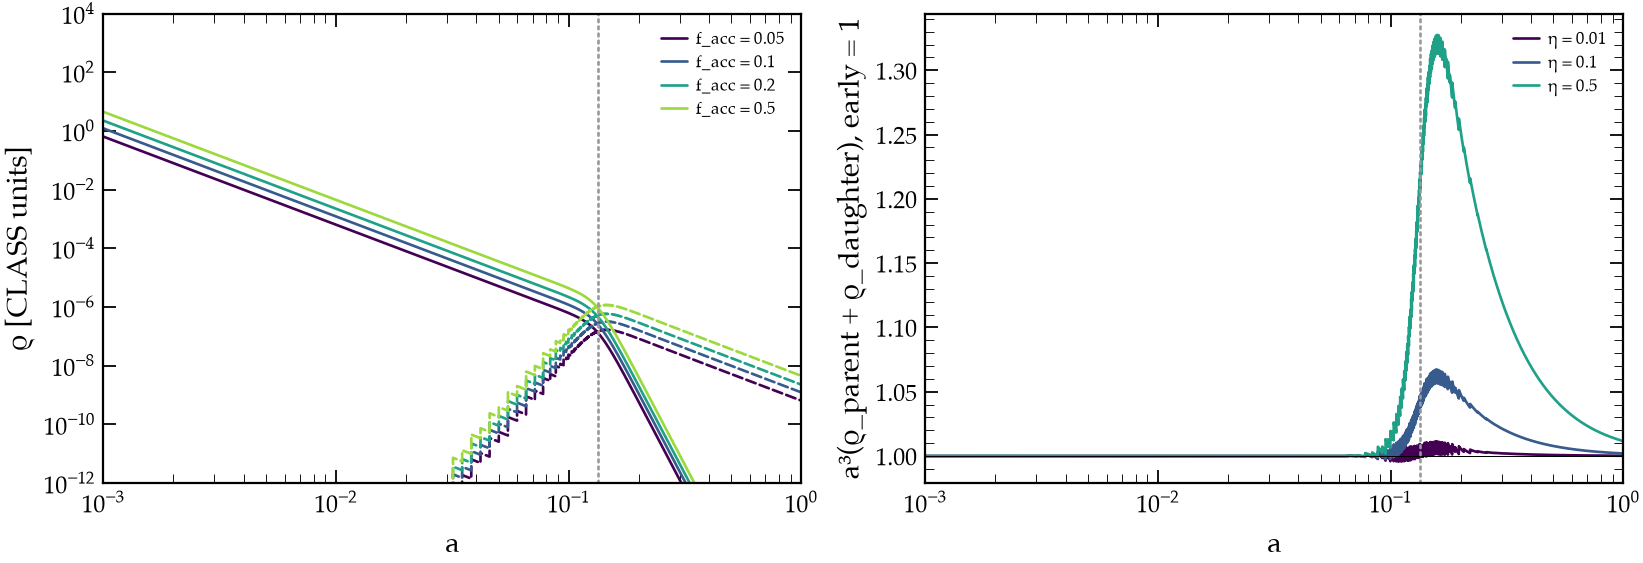

   eta       peak      today
  0.01    1.01137    1.00018
   0.1    1.06724    1.00194
   0.5    1.32758    1.01149


In [6]:
ETA_SEQ = [0.01, 0.1, 0.5]
runs_eta = {e: background(F_FID, eta=e) for e in ETA_SEQ}
colors = plt.cm.viridis(np.linspace(0, 0.85, 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for (f, b), c in zip(runs_f.items(), colors):
    axes[0].loglog(b['a'], b['(.)rho_acc_cdm'], color=c, label='f_acc = {:g}'.format(f))
    axes[0].loglog(b['a'], b['(.)rho_ncdm[1]'], color=c, ls='--')
axes[0].set_ylim(1e-12, 1e4)
axes[0].set_ylabel('ρ [CLASS units]')
for (e, b), c in zip(runs_eta.items(), colors):
    sector = b['a']**3*(b['(.)rho_acc_cdm'] + b['(.)rho_ncdm[1]'])
    axes[1].semilogx(b['a'], sector/sector[np.argmax(b['a'] > 1e-3)], color=c, label='η = {:g}'.format(e))
axes[1].axhline(1, color='k', lw=0.5)
axes[1].set_ylabel('a³(ρ_parent + ρ_daughter), early = 1')
for ax in axes:
    ax.axvline(A_T, color='0.6', ls=':')
    ax.set_xlim(1e-3, 1)
    ax.set_xlabel('a')
    ax.legend(fontsize=8)
plt.show()

print('{:>6} {:>10} {:>10}'.format('eta', 'peak', 'today'))
for e, b in runs_eta.items():
    sector = b['a']**3*(b['(.)rho_acc_cdm'] + b['(.)rho_ncdm[1]'])
    norm = sector/sector[np.argmax(b['a'] > 1e-3)]
    print('{:>6g} {:>10.5f} {:>10.5f}'.format(e, norm.max(), norm[-1]))